# Dataset A: NSW Train Occupancy Analysis
## COMP5310 Principles of Data Science — Project Stage 2

**Group:** Lab_014 — Group 4  
**Dataset:** NSW Train Occupancy (Dataset A)  
**Author:** Rahul Srinivas Selvaraju

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

---
## Section 1: Topic Selection & Problem Definition

### Why NSW Train Occupancy?
The NSW Train Occupancy dataset was selected over the Air Delay 
and Hotel Bookings datasets for the following reasons:

1. **Clear classification problem** — The target variable 
(Occupancy Status) has 3 meaningful, well-defined categories 
making it directly suited to supervised classification algorithms.

2. **Strong Stage 1 EDA findings** — Stage 1 analysis revealed 
highly interpretable patterns: direction (Up/Down), station 
sequence (Node.Seq.Order ranging 1–38), and service line were 
all strongly associated with occupancy patterns, confirming 
these as meaningful predictors for Stage 2 modelling.

3. **Real-world impact** — Predicting train occupancy directly 
benefits Transport for NSW, commuters, and city planners by 
enabling smarter travel decisions and optimised scheduling.

4. **Significant ML challenge** — Stage 1 revealed severe class 
imbalance (96.0% MANY_SEATS_AVAILABLE, 3.2% FEW_SEATS_AVAILABLE, 
0.8% STANDING_ROOM_ONLY), presenting a meaningful opportunity to 
apply and evaluate imbalance-handling techniques.

### Research Question
> *"Can we predict a train's occupancy status (empty, few seats, 
or standing room only) based on route direction, station sequence, 
service line, and time of day?"*

This research question is carried forward from Stage 1 with no 
modification, as the EDA confirmed all selected features show 
meaningful variation with respect to occupancy — validating the 
original problem formulation.

### Problem Type
**Multi-class Classification** — predicting one of 3 discrete 
occupancy categories.

### Target Variable
`Occupancy Status` encoded as:
- **0** = MANY_SEATS_AVAILABLE (n = 47,505 — 96.0%)
- **1** = FEW_SEATS_AVAILABLE (n = 1,581 — 3.2%)
- **2** = STANDING_ROOM_ONLY (n = 396 — 0.8%)

---
## Section 2: Data Description & Feature Preparation

### Stage 1 Summary
The raw dataset contained **50,250 rows and 14 columns**. 
After cleaning in Stage 1:
- Removed duplicates and null values
- Fixed inconsistent capitalisation in `Occupancy Status`
- Fixed trailing whitespace in `Segment.Direction`
- **Final cleaned shape: 49,482 rows × 14 columns**

### Key Challenge: Class Imbalance & Implications for Modelling
Stage 1 EDA revealed severe class imbalance in the target variable:
- MANY_SEATS_AVAILABLE → 47,505 records (96.0%)
- FEW_SEATS_AVAILABLE → 1,581 records (3.2%)
- STANDING_ROOM_ONLY → 396 records (0.8%)

**Implications for modelling:**
- A naive model that always predicts MANY_SEATS_AVAILABLE would 
  achieve 96% accuracy while being completely uninformative
- Standard accuracy is therefore a misleading metric — 
  **macro F1-score** must be used to evaluate all 3 classes equally
- All models must use `class_weight='balanced'` to prevent 
  the model from ignoring minority classes
- This imbalance reflects real-world reality — crowded trains 
  are genuinely rare events, making their correct prediction 
  especially valuable

### Step 1: Load Cleaned Dataset

In [28]:
df = pd.read_csv('train_occupancy_cleaned.csv')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (49482, 14)

Column names:
['day', 'Actual.Stop.Station', 'Actual.Station.Arrv.Time', 'Actual.Station.Dprt.Time', 'Segment.Direction', 'Trip.Name', 'Service.Line', 'Orig..Station', 'Dest..Station', 'Leading.Set.Type', 'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status', 'Occupancy Range']

First 5 rows:


,day,Actual.Stop.Station,Actual.Station.Arrv.Time,Actual.Station.Dprt.Time,Segment.Direction,Trip.Name,Service.Line,Orig..Station,Dest..Station,Leading.Set.Type,Node.Seq.Order,Actual.Station.Dprt.Time.Band,Occupancy Status,Occupancy Range
0,9,Miranda,2017-01-10 00:18:17,2017-01-10 00:19:04,Down,620S,Illawarra,Central,Cronulla,T,18,00:15-00:29,MANY_SEATS_AVAILABLE,Low: 0-399
1,13,Beecroft,2017-01-13 08:05:59,2017-01-13 08:06:56,Down,152C,North via Macquarie Park,Central,Hornsby,A,16,08:00-08:14,MANY_SEATS_AVAILABLE,Low: 0-399
2,12,Arncliffe,2017-01-12 07:22:51,2017-01-12 07:23:36,Down,607B,Illawarra,Central,Waterfall,T,6,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
3,13,Dulwich Hill,2017-01-13 07:20:39,2017-01-13 07:21:53,Down,58-F,Bankstown,Central,Birrong,A,7,07:15-07:29,MANY_SEATS_AVAILABLE,Low: 0-399
4,11,Belmore,2017-01-11 18:38:28,2017-01-11 18:39:07,Up,33-P,Bankstown,Birrong,Central,K,7,18:30-18:44,MANY_SEATS_AVAILABLE,Low: 0-399


### Class Imbalance Visualisation

The bar chart below clearly demonstrates the severe class imbalance 
in the target variable. MANY_SEATS_AVAILABLE dominates at 96% of 
all records, while FEW_SEATS_AVAILABLE (3.2%) and STANDING_ROOM_ONLY 
(0.8%) are barely visible in comparison.

This visualisation directly supports the need for:
- `class_weight='balanced'` in all models
- **Macro F1-score** as the primary evaluation metric rather than accuracy

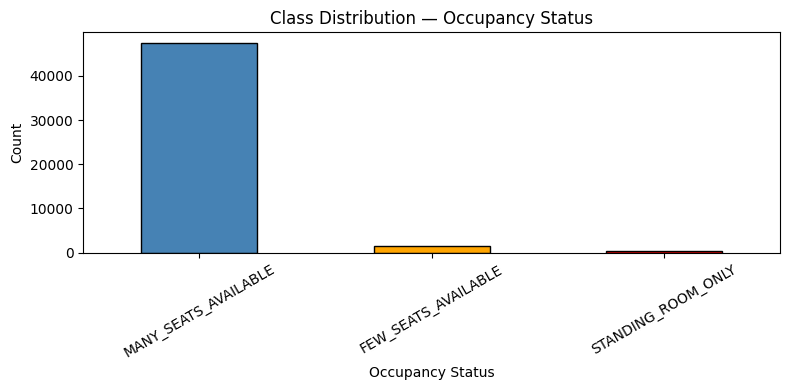

In [29]:
# Visualise class imbalance
plt.figure(figsize=(8, 4))
df['Occupancy Status'].value_counts().plot(
    kind='bar', 
    color=['steelblue', 'orange', 'red'],
    edgecolor='black'
)
plt.title('Class Distribution — Occupancy Status')
plt.xlabel('Occupancy Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [30]:
# See all 14 columns with their data types and sample values
print("All columns and data types:")
print(df.dtypes)
print("\nBasic statistics for numerical columns:")
print(df.describe())

All columns and data types:
day                              int64
Actual.Stop.Station                str
Actual.Station.Arrv.Time           str
Actual.Station.Dprt.Time           str
Segment.Direction                  str
Trip.Name                          str
Service.Line                       str
Orig..Station                      str
Dest..Station                      str
Leading.Set.Type                   str
Node.Seq.Order                   int64
Actual.Station.Dprt.Time.Band      str
Occupancy Status                   str
Occupancy Range                    str
dtype: object

Basic statistics for numerical columns:
                day  Node.Seq.Order
count  49482.000000    49482.000000
mean      12.804596        8.890607
std        2.034621        6.045419
min        9.000000        1.000000
25%       11.000000        4.000000
50%       13.000000        8.000000
75%       15.000000       13.000000
max       16.000000       38.000000


### Step 2: Feature Selection

After reviewing all 14 columns, the following were **dropped**:

| Column | Reason |
|---|---|
| `Actual.Station.Arrv.Time` | Raw timestamp — too specific, no general pattern |
| `Actual.Station.Dprt.Time` | Raw timestamp — same reason |
| `Trip.Name` | Unique trip ID — no predictive value |
| `Orig..Station` | Redundant with `Service.Line` |
| `Dest..Station` | Redundant with `Service.Line` |
| `Occupancy Range` | Another form of the target — **data leakage!** |

The remaining **8 columns** were retained as features + target.

In [31]:
# Step 2: Feature Selection
# Dropping columns that are IDs, redundant, or leak the target

columns_to_drop = [
    'Actual.Station.Arrv.Time',   # Raw timestamp - too specific
    'Actual.Station.Dprt.Time',   # Raw timestamp - too specific  
    'Trip.Name',                   # Just a trip ID - no predictive value
    'Orig..Station',               # Redundant with Service.Line
    'Dest..Station',               # Redundant with Service.Line
    'Occupancy Range'              # Another version of our target - data leakage!
]

df_model = df.drop(columns=columns_to_drop)

print("Columns remaining:", df_model.columns.tolist())
print("Shape after dropping:", df_model.shape)

Columns remaining: ['day', 'Actual.Stop.Station', 'Segment.Direction', 'Service.Line', 'Leading.Set.Type', 'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status']
Shape after dropping: (49482, 8)


### Step 3: Feature Engineering

Two new features were engineered to improve model performance:

1. **`is_weekend`** — derived from `day`. Days 14 and 15 
correspond to Saturday and Sunday, confirmed by significantly 
lower service counts observed in Stage 1 EDA. Weekend trains 
show different occupancy patterns to weekdays.

2. **`is_peak`** — derived from `Actual.Station.Dprt.Time.Band`. 
Morning peak (7–9am) and evening peak (4–6pm) are known 
high-demand periods in the NSW rail network. First, we explore 
the unique time band values to confirm the data format before 
creating this feature.

In [32]:
# Step 3: Feature Engineering
# First let's see what unique values are in the time band column
print("Time Band unique values:")
print(df_model['Actual.Station.Dprt.Time.Band'].value_counts())

print("\nDay unique values:")
print(df_model['day'].value_counts().sort_index())

Time Band unique values:
Actual.Station.Dprt.Time.Band
08:00-08:14    857
08:15-08:29    827
17:15-17:29    809
17:30-17:44    799
09:00-09:14    798
              ... 
02:30-02:44     34
02:45-02:59     32
02:15-02:29     29
03:15-03:29     26
03:00-03:14     25
Name: count, Length: 96, dtype: int64

Day unique values:
day
9      164
10    7836
11    7935
12    7814
13    7866
14    5165
15    5092
16    7610
Name: count, dtype: int64


#### Creating the Engineered Features

The time band column uses 15-minute interval format 
(e.g. "08:00-08:14"). We extract the hour from the first 
2 characters to determine peak vs off-peak, then drop 
the temporary `hour` column after `is_peak` is created.

In [33]:
# Step 3: Feature Engineering

# Feature 1 - is_weekend
# Day 14 = Saturday, Day 15 = Sunday (confirmed by lower service counts)
df_model['is_weekend'] = df_model['day'].apply(lambda x: 1 if x in [14, 15] else 0)

# Feature 2 - is_peak
# Extract just the hour from time band e.g. "08:00-08:14" → 8
df_model['hour'] = df_model['Actual.Station.Dprt.Time.Band'].str[:2].astype(int)

# Morning peak = 7am-9am, Evening peak = 4pm-6pm
df_model['is_peak'] = df_model['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

# Check results
print("is_weekend distribution:")
print(df_model['is_weekend'].value_counts())

print("\nis_peak distribution:")
print(df_model['is_peak'].value_counts())

print("\nFinal columns:", df_model.columns.tolist())

is_weekend distribution:
is_weekend
0    39225
1    10257
Name: count, dtype: int64

is_peak distribution:
is_peak
0    31424
1    18058
Name: count, dtype: int64

Final columns: ['day', 'Actual.Stop.Station', 'Segment.Direction', 'Service.Line', 'Leading.Set.Type', 'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status', 'is_weekend', 'hour', 'is_peak']


### Step 4: Encoding Categorical Variables

Machine learning models require **numerical inputs only**. 
All remaining text columns are converted to numbers using 
`LabelEncoder` from sklearn.

The **target column** `Occupancy Status` is encoded manually 
so the class mapping is explicit and fully documented:
- **0** = MANY_SEATS_AVAILABLE
- **1** = FEW_SEATS_AVAILABLE
- **2** = STANDING_ROOM_ONLY

In [34]:
# Step 4: Encode Categorical Columns

le = LabelEncoder()

# Encode each categorical column
categorical_cols = [
    'Actual.Stop.Station',
    'Segment.Direction',
    'Service.Line',
    'Leading.Set.Type',
    'Actual.Station.Dprt.Time.Band'
]

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Encode target column separately so we can see the mapping
df_model['Occupancy Status'] = df_model['Occupancy Status'].map({
    'MANY_SEATS_AVAILABLE': 0,
    'FEW_SEATS_AVAILABLE': 1,
    'STANDING_ROOM_ONLY': 2
})

print("After encoding:")
print(df_model.head())
print("\nOccupancy Status distribution:")
print(df_model['Occupancy Status'].value_counts())
print("\nAll dtypes now:")
print(df_model.dtypes)

After encoding:
   day  Actual.Stop.Station  Segment.Direction  Service.Line  \
0    9                  175                  0            13   
1   13                   16                  0            19   
2   12                    4                  0            13   
3   13                   78                  0             2   
4   11                   19                  1             2   

   Leading.Set.Type  Node.Seq.Order  Actual.Station.Dprt.Time.Band  \
0                 8              18                              1   
1                 0              16                             32   
2                 8               6                             29   
3                 0               7                             29   
4                 4               7                             74   

   Occupancy Status  is_weekend  hour  is_peak  
0                 0           0     0        0  
1                 0           0     8        1  
2                 0           0

### Step 5: Final Cleanup & Save Model-Ready Dataset

The temporary `hour` column (used only to create `is_peak`) 
is removed. The final dataset is verified and saved as 
`train_occupancy_model_ready.csv` for teammates to use 
directly for model training and evaluation.

**Final feature set:**

| Feature | Type | Description |
|---|---|---|
| `day` | Numerical | Day of month (9–16) |
| `Actual.Stop.Station` | Encoded | Station where reading was taken |
| `Segment.Direction` | Encoded | Up or Down direction |
| `Service.Line` | Encoded | Train line (Illawarra, Bankstown etc.) |
| `Leading.Set.Type` | Encoded | Type of train set |
| `Node.Seq.Order` | Numerical | Stop sequence number along route |
| `Actual.Station.Dprt.Time.Band` | Encoded | 15-min departure time band |
| `is_weekend` | Binary | 1 = Saturday/Sunday, 0 = Weekday |
| `is_peak` | Binary | 1 = Peak hours (7–9am or 4–6pm), 0 = Off-peak |
| **`Occupancy Status`** | **TARGET** | **0 = Many seats, 1 = Few seats, 2 = Standing** |

> **Note for teammates (Person 2 & 3):** Load 
`train_occupancy_model_ready.csv` directly. Use 
`class_weight='balanced'` in all models and report 
**macro F1-score** as the primary evaluation metric 
due to class imbalance.

In [35]:
# Step 5: Final cleanup and save

# Drop 'hour' column - it was only needed to create is_peak
df_model = df_model.drop(columns=['hour'])

# Verify all 3 occupancy classes are present
print("Final Occupancy Status distribution:")
print(df_model['Occupancy Status'].value_counts().sort_index())
print("\nClass meaning:")
print("0 = MANY_SEATS_AVAILABLE")
print("1 = FEW_SEATS_AVAILABLE")
print("2 = STANDING_ROOM_ONLY")

# Final shape and columns
print(f"\nFinal dataset shape: {df_model.shape}")
print(f"Final columns: {df_model.columns.tolist()}")

# Verify all columns are now numbers (no more text)
print(f"\nAll dtypes:")
print(df_model.dtypes)

# Save the model-ready CSV
df_model.to_csv('train_occupancy_model_ready.csv', index=False)
print("\n Model-ready CSV saved successfully!")
print("Teammates can now load: train_occupancy_model_ready.csv")

Final Occupancy Status distribution:
Occupancy Status
0    47505
1     1581
2      396
Name: count, dtype: int64

Class meaning:
0 = MANY_SEATS_AVAILABLE
1 = FEW_SEATS_AVAILABLE
2 = STANDING_ROOM_ONLY

Final dataset shape: (49482, 10)
Final columns: ['day', 'Actual.Stop.Station', 'Segment.Direction', 'Service.Line', 'Leading.Set.Type', 'Node.Seq.Order', 'Actual.Station.Dprt.Time.Band', 'Occupancy Status', 'is_weekend', 'is_peak']

All dtypes:
day                              int64
Actual.Stop.Station              int64
Segment.Direction                int64
Service.Line                     int64
Leading.Set.Type                 int64
Node.Seq.Order                   int64
Actual.Station.Dprt.Time.Band    int64
Occupancy Status                 int64
is_weekend                       int64
is_peak                          int64
dtype: object

 Model-ready CSV saved successfully!
Teammates can now load: train_occupancy_model_ready.csv
